# Model Training

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader
from itertools import product as iterproduct
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
from utils.helper import (set_seed, load_data, preprocess, load_processed_data, load_processed_data,
                    print_split_summary, AugmentedDataset, evaluate, ESRI_LULC_CLASSES)
from torchinfo import summary
set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {device}")
PATCH_SIZE = 32
STRIDE = 8


Device : cuda


## Loading the Processed Data 

In [2]:
# Loading Processed Balanced Dataset
splits = load_processed_data("../processed_data")
print_split_summary(splits)

X_train, y_train, c_train = splits["X_train"], splits["y_train"], splits["c_train"]
X_val, y_val, c_val = splits["X_val"], splits["y_val"], splits["c_val"]
X_test, y_test, c_test = splits["X_test"], splits["y_test"], splits["c_test"]

num_classes = splits["num_classes"]
unique_labels = splits["unique_labels"]
label_map = splits["label_map"]
in_channels = splits.get("in_channels", 5)

class_names = [ESRI_LULC_CLASSES[int(k)][0] if int(k) in ESRI_LULC_CLASSES else f"Class {int(k)}" for k in unique_labels]
print(f"\nClass names : {class_names}")

Loading dataset from ../processed_data
Patch size : 32 × 32
Channels : 5

Subset        Samples                X_Shape                y_Shape
──────────────────────────────────────────────────────────────────────
train           1,090         (1090, 5, 32, 32)         (1090, 32, 32)
val               183          (183, 5, 32, 32)          (183, 32, 32)
test              183          (183, 5, 32, 32)          (183, 32, 32)

Classes labels changed : ['0 to 0', '1 to 1', '2 to 2', '7 to 3', '11 to 4']

Class names : ['Unlabeled Data', 'Water', 'Trees', 'Built Area', 'Rangeland']


In [3]:
class_cnt = np.bincount(y_train.flatten())
class_wgt = 1.0/(class_cnt+1e-6)
class_wgt = class_wgt/class_wgt.sum()
W = torch.tensor(class_wgt, dtype=torch.float32).to(device)

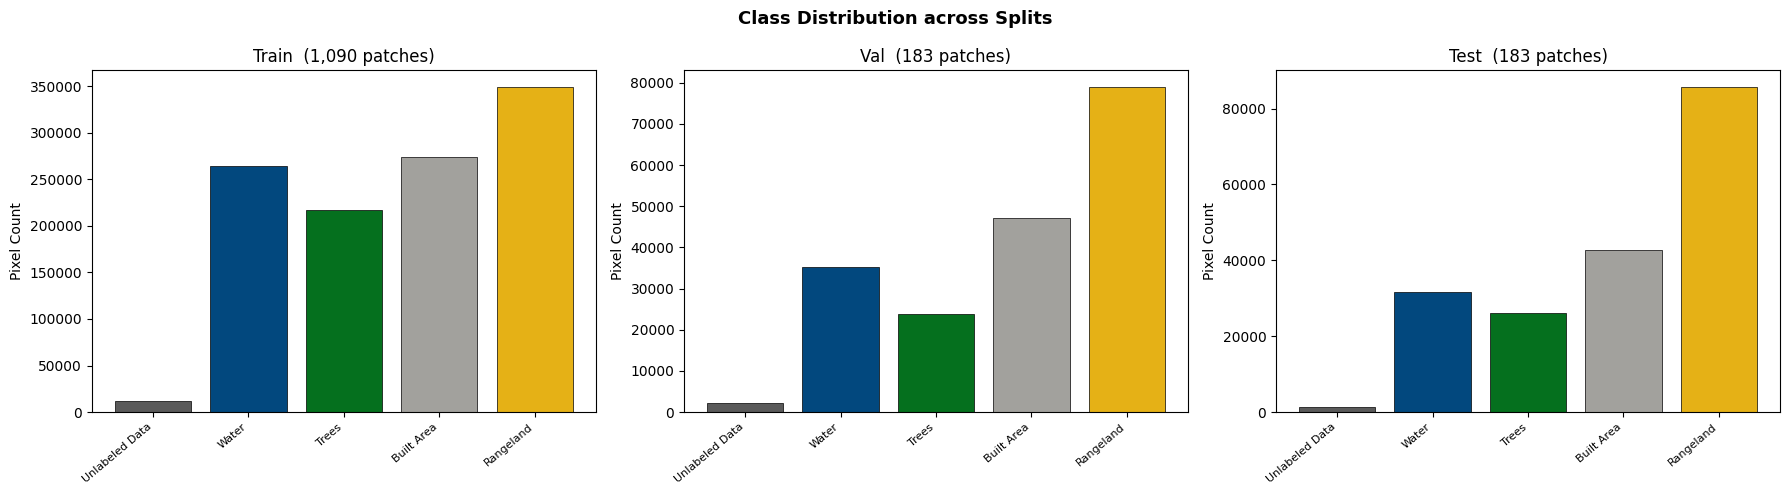

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle("Class Distribution across Splits", fontsize=13, fontweight="bold")
colors = [ESRI_LULC_CLASSES[int(k)][1] if int(k) in ESRI_LULC_CLASSES else "#888888" for k in unique_labels]

for ax, (y_split, name) in zip(axes, [(y_train,"Train"),(y_val,"Val"),(y_test,"Test")]):
    counts = [np.sum(y_split == i) for i in range(num_classes)]
    ax.bar(class_names, counts, color=colors, edgecolor="k", linewidth=0.5)
    ax.set_title(f"{name}  ({len(y_split):,} patches)")
    ax.set_xticks(range(len(class_names))) 
    ax.set_xticklabels(class_names, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("Pixel Count")
    
plt.tight_layout()
plt.show()

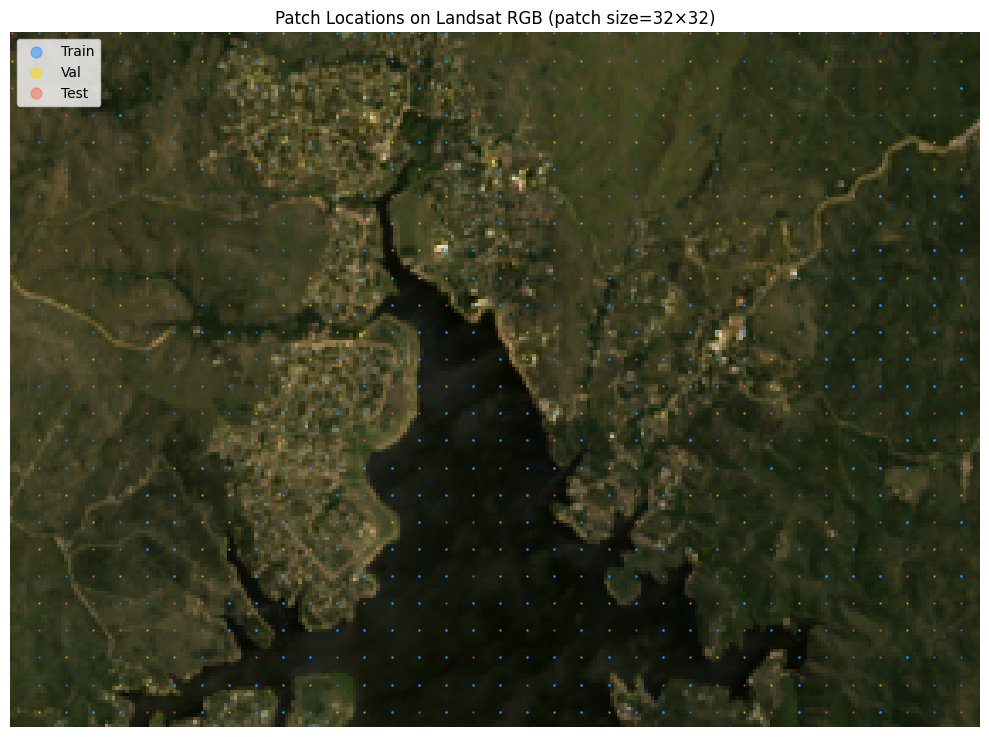

In [5]:
ls_data, lulc_data = load_data(base_path="../landsat_data/", lulc_path="lulc.tif")
ls_scaled, ndvi, rgb_vis = preprocess(ls_data)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(np.transpose(rgb_vis, (1, 2, 0)))
h, w = rgb_vis.shape[1], rgb_vis.shape[2]
ax.scatter(np.clip(c_train[:,1], 0, w-1), np.clip(c_train[:,0], 0, h-1), c="dodgerblue", s=0.6, label="Train", alpha=0.5)
ax.scatter(np.clip(c_val[:,1], 0, w-1), np.clip(c_val[:,0], 0, h-1), c="gold", s=0.6, label="Val", alpha=0.5)
ax.scatter(np.clip(c_test[:,1], 0, w-1), np.clip(c_test[:,0], 0, h-1), c="tomato", s=0.6, label="Test", alpha=0.5)
ax.set_title(f"Patch Locations on Landsat RGB (patch size={PATCH_SIZE}×{PATCH_SIZE})", fontsize=12)
ax.legend(markerscale=10, fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()

## Training Loop

In [6]:
EPOCHS = 30
BATCH_SIZE = 32

def train_model(model, model_name, X_tr, y_tr, X_vl, y_vl, lr=1e-3, epochs=EPOCHS, batch_size=BATCH_SIZE, scheduler_type="cosine"):
    model.to(device)
    criterion = nn.CrossEntropyLoss(weight=W)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    if scheduler_type == "cosine":
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    elif scheduler_type == "step":
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    else:
        scheduler = None

    train_ds = AugmentedDataset(X_tr, y_tr)
    val_ds = AugmentedDataset(X_vl, y_vl)
    train_ld = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    val_ld = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "epoch_time": []}
    total_t0 = time.time()
    print(f"\n{'='*62}")
    print(f"{'TRAINING STARTED':^62}")
    print(f"{'='*62}\n")

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        model.train()
        running_loss, train_correct, train_total = 0.0, 0, 0
        for bx, by in train_ld:
            optimizer.zero_grad()
            out = model(bx.to(device))
            loss = criterion(out, by.to(device))
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(bx)
            train_correct += (out.argmax(dim=1).cpu() == by).sum().item()
            train_total += by.numel()

        avg_train_loss = running_loss / len(train_ds)
        train_acc = train_correct / train_total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for bx, by in val_ld:
                out = model(bx.to(device))
                val_loss += criterion(out, by.to(device)).item() * len(bx)
                val_correct += (out.argmax(dim=1).cpu() == by).sum().item()
                val_total += by.numel()

        avg_val_loss = val_loss / len(val_ds)
        val_acc = val_correct / val_total

        if scheduler: 
            scheduler.step()

        ep_time = time.time()-t0
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(ep_time)

        print(f"[Epoch {epoch:02d}/{epochs}] "
              f"Loss={avg_train_loss:.4f}  "
              f"ValAcc={val_acc:.4f}  "
              f"Time={ep_time:.2f}s")

    total_time = time.time()-total_t0
    print(f"\n Training Finished")
    print(f"\nTotal Time Taken : {total_time:.2f}s")
    print(f"Average Time Taken per epoch : {total_time/epochs:.2f}s")
    return model, history


def plot_history(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Training History – {model_name}", fontsize=13, fontweight="bold")

    ax1.plot(history["train_loss"], color="steelblue", linewidth=2, label="Train Loss")
    ax1.plot(history["val_loss"], color="tomato", linewidth=2, label="Val Loss")
    ax1.set_title("Loss per Epoch")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(history["train_acc"], color="steelblue", linewidth=2, label="Train Acc")
    ax2.plot(history["val_acc"], color="seagreen", linewidth=2, label="Val Acc")
    ax2.set_title("Accuracy per Epoch")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_ylim(0, 1)
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

comparison_metrics = {}

## Model 1 - U-Net

In [7]:
def conv_block(in_c, out_c):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
        nn.Conv2d(out_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
    )

class UNet(nn.Module):
    def __init__(self, in_channels, num_classes, base_filters=32, dropout=0.30):
        super().__init__()
        f = base_filters
        self.enc1 = conv_block(in_channels, f)
        self.enc2 = conv_block(f,f*2)
        self.bottleneck= conv_block(f*2,f*4)
        self.up2 = nn.ConvTranspose2d(f*4,f*2,2,stride=2)
        self.dec2 = conv_block(f*4,f*2)
        self.up1 = nn.ConvTranspose2d(f*2,f,2,stride=2)
        self.dec1 = conv_block(f*2,f)
        self.drop = nn.Dropout(p=dropout)
        self.pool = nn.MaxPool2d(2, 2)
        self.final_conv = nn.Conv2d(f, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        b = self.bottleneck(self.pool(e2))
        d2 = self.dec2(torch.cat([self.up2(b),e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2),e1], dim=1))
        
        return self.final_conv(d1)

In [8]:
# Summary of the model 

unet = UNet(in_channels, num_classes).to(device)
summary(unet, input_size=(1, in_channels, PATCH_SIZE, PATCH_SIZE),col_names=["input_size","output_size","num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
UNet                                     [1, 5, 32, 32]            [1, 5, 32, 32]            --
├─Sequential: 1-1                        [1, 5, 32, 32]            [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 5, 32, 32]            [1, 32, 32, 32]           1,472
│    └─BatchNorm2d: 2-2                  [1, 32, 32, 32]           [1, 32, 32, 32]           64
│    └─ReLU: 2-3                         [1, 32, 32, 32]           [1, 32, 32, 32]           --
│    └─Conv2d: 2-4                       [1, 32, 32, 32]           [1, 32, 32, 32]           9,248
│    └─BatchNorm2d: 2-5                  [1, 32, 32, 32]           [1, 32, 32, 32]           64
│    └─ReLU: 2-6                         [1, 32, 32, 32]           [1, 32, 32, 32]           --
├─MaxPool2d: 1-2                         [1, 32, 32, 32]           [1, 32, 16, 16]           --
├─Sequential: 1-3            

In [9]:
unet, unet_history = train_model( unet, "U-Net", X_train, y_train, X_val, y_val, lr=5e-4, epochs=EPOCHS, scheduler_type="cosine")


                       TRAINING STARTED                       

[Epoch 01/30] Loss=1.1800  ValAcc=0.5379  Time=0.72s
[Epoch 02/30] Loss=0.9174  ValAcc=0.8233  Time=0.36s
[Epoch 03/30] Loss=0.7816  ValAcc=0.7972  Time=0.30s
[Epoch 04/30] Loss=0.7253  ValAcc=0.6951  Time=0.30s
[Epoch 05/30] Loss=0.6621  ValAcc=0.8222  Time=0.31s
[Epoch 06/30] Loss=0.5910  ValAcc=0.7157  Time=0.32s
[Epoch 07/30] Loss=0.5756  ValAcc=0.8148  Time=0.31s
[Epoch 08/30] Loss=0.5173  ValAcc=0.8346  Time=0.29s
[Epoch 09/30] Loss=0.4828  ValAcc=0.8751  Time=0.31s
[Epoch 10/30] Loss=0.4775  ValAcc=0.7750  Time=0.30s
[Epoch 11/30] Loss=0.4504  ValAcc=0.7817  Time=0.29s
[Epoch 12/30] Loss=0.4543  ValAcc=0.8475  Time=0.28s
[Epoch 13/30] Loss=0.4015  ValAcc=0.8930  Time=0.28s
[Epoch 14/30] Loss=0.3494  ValAcc=0.8884  Time=0.27s
[Epoch 15/30] Loss=0.3360  ValAcc=0.8414  Time=0.28s
[Epoch 16/30] Loss=0.3084  ValAcc=0.8405  Time=0.28s
[Epoch 17/30] Loss=0.3080  ValAcc=0.9126  Time=0.28s
[Epoch 18/30] Loss=0.2911  ValAcc=

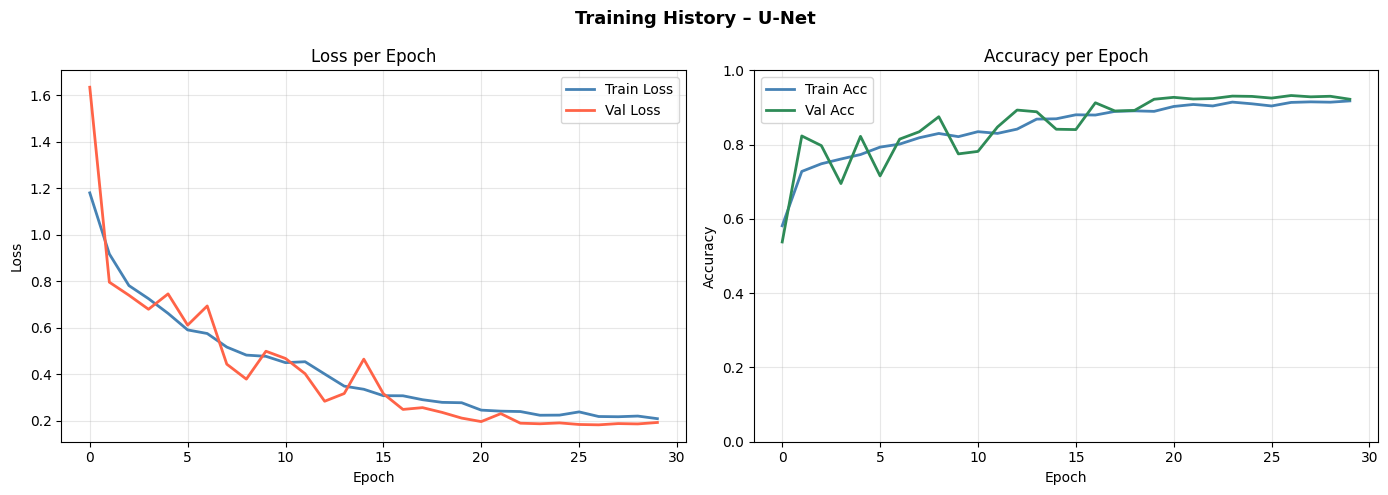

In [10]:
plot_history(unet_history,"U-Net")


 Training Metrics 

────────────────────────────────────────────────────
Evaluation    U-Net Train
────────────────────────────────────────────────────
Accuracy        : 0.9161
Precision       : 0.9239
Recall          : 0.9161
F1 Score        : 0.9165
Log Loss        : 0.2510
IoU (Jaccard)   : 0.8493
Dice Score      : 0.9185
────────────────────────────────────────────────────


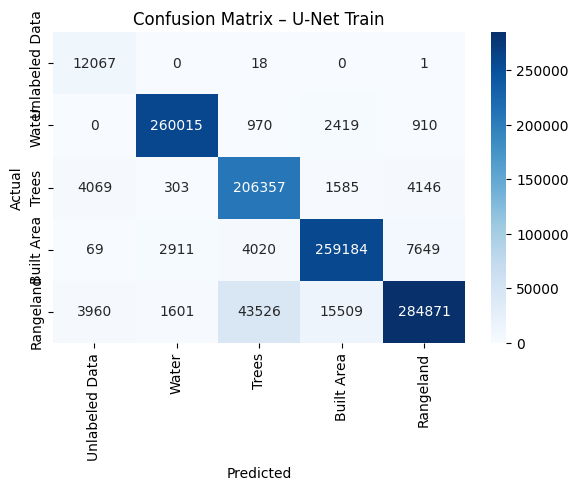

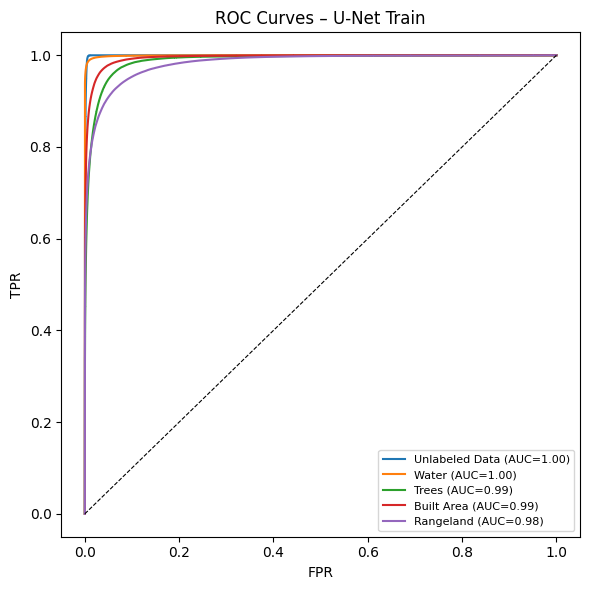

In [11]:
print("\n Training Metrics ")
unet_train_m = evaluate(unet, X_train, y_train, num_classes, device, class_names, "U-Net Train", show_cm=True, show_roc=True)


 Validation Metrics 

────────────────────────────────────────────────────
Evaluation    U-Net Validation
────────────────────────────────────────────────────
Accuracy        : 0.9222
Precision       : 0.9300
Recall          : 0.9222
F1 Score        : 0.9236
Log Loss        : 0.2379
IoU (Jaccard)   : 0.8606
Dice Score      : 0.9251
────────────────────────────────────────────────────


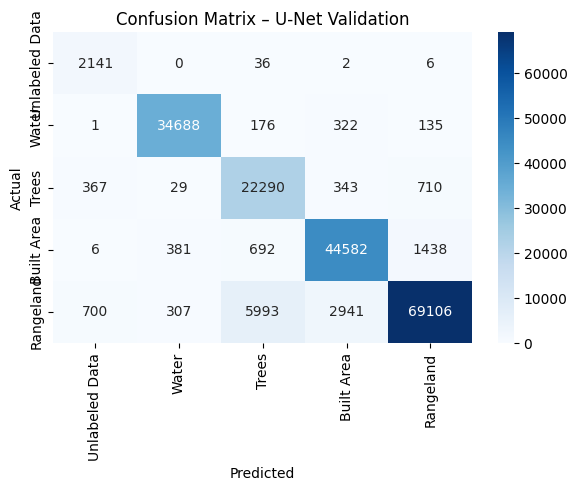

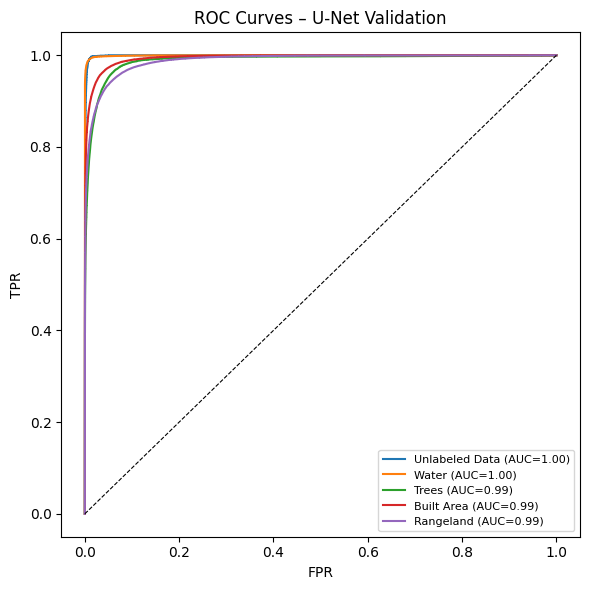

In [12]:
print("\n Validation Metrics ")
unet_val_m = evaluate(unet, X_val, y_val, num_classes, device, class_names, "U-Net Validation", show_cm=True, show_roc=True)


 Testing Metrics

────────────────────────────────────────────────────
Evaluation    U-Net Testing
────────────────────────────────────────────────────
Accuracy        : 0.9194
Precision       : 0.9297
Recall          : 0.9194
F1 Score        : 0.9215
Log Loss        : 0.2440
IoU (Jaccard)   : 0.8576
Dice Score      : 0.9233
────────────────────────────────────────────────────


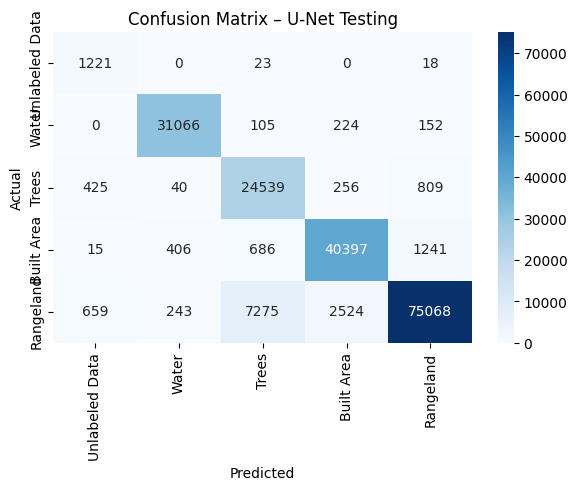

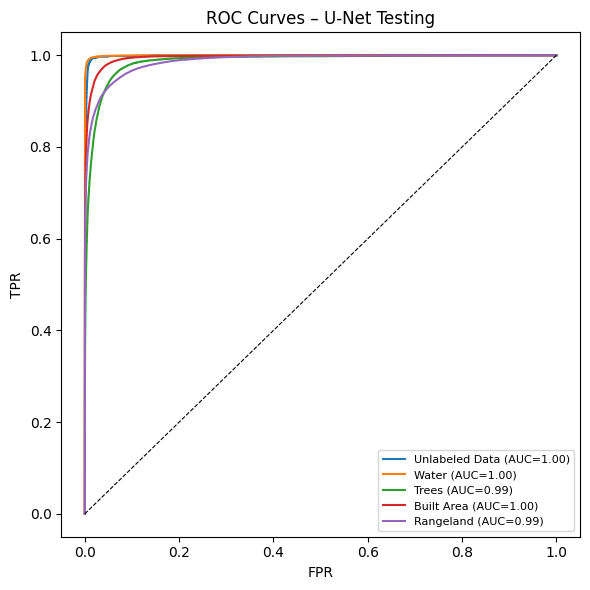

In [13]:
print("\n Testing Metrics")
unet_test_m = evaluate(unet, X_test, y_test, num_classes, device, class_names, "U-Net Testing", show_cm=True, show_roc=True)

comparison_metrics["U-Net"] = unet_test_m

## Model 2 - ResUNet

In [14]:
class ResBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1, dropout=0.30):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_c)
        self.drop = nn.Dropout2d(p=dropout)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, stride=stride), nn.BatchNorm2d(out_c))

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.drop(self.bn2(self.conv2(out)))
        return F.relu(out + self.shortcut(x))

class ResUNet(nn.Module):
    def __init__(self, in_channels, num_classes, base_filters=32, dropout=0.0):
        super().__init__()
        f = base_filters
        self.enc1 = ResBlock(in_channels,f,dropout=dropout)
        self.enc2 = ResBlock(f,f*2,stride=2,dropout=dropout)
        self.bottleneck = ResBlock(f*2,f*4,stride=2,dropout=dropout)
        self.up2 = nn.ConvTranspose2d(f*4,f*2,2,stride=2)
        self.dec2 = ResBlock(f*4,f*2,dropout=dropout)
        self.up1 = nn.ConvTranspose2d(f*2,f,2,stride=2)
        self.dec1 = ResBlock(f*2,f,dropout=dropout)
        self.final_conv = nn.Conv2d(f,num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        b = self.bottleneck(e2)
        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.final_conv(d1)

In [15]:
# Summary of the model 

resunet = ResUNet(in_channels, num_classes).to(device)
summary(resunet, input_size=(1, in_channels, PATCH_SIZE, PATCH_SIZE), col_names=["input_size","output_size","num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
ResUNet                                  [1, 5, 32, 32]            [1, 5, 32, 32]            --
├─ResBlock: 1-1                          [1, 5, 32, 32]            [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 5, 32, 32]            [1, 32, 32, 32]           1,472
│    └─BatchNorm2d: 2-2                  [1, 32, 32, 32]           [1, 32, 32, 32]           64
│    └─Conv2d: 2-3                       [1, 32, 32, 32]           [1, 32, 32, 32]           9,248
│    └─BatchNorm2d: 2-4                  [1, 32, 32, 32]           [1, 32, 32, 32]           64
│    └─Dropout2d: 2-5                    [1, 32, 32, 32]           [1, 32, 32, 32]           --
│    └─Sequential: 2-6                   [1, 5, 32, 32]            [1, 32, 32, 32]           --
│    │    └─Conv2d: 3-1                  [1, 5, 32, 32]            [1, 32, 32, 32]           192
│    │    └─BatchNorm2d: 3-2

In [16]:
resunet, resunet_history = train_model(resunet, "ResUNet", X_train, y_train, X_val, y_val, lr=5e-4, epochs=EPOCHS, scheduler_type="cosine" )


                       TRAINING STARTED                       

[Epoch 01/30] Loss=0.9999  ValAcc=0.5217  Time=0.56s
[Epoch 02/30] Loss=0.7341  ValAcc=0.4966  Time=0.45s
[Epoch 03/30] Loss=0.6527  ValAcc=0.7047  Time=0.47s
[Epoch 04/30] Loss=0.5976  ValAcc=0.7604  Time=0.45s
[Epoch 05/30] Loss=0.5247  ValAcc=0.7713  Time=0.39s
[Epoch 06/30] Loss=0.4983  ValAcc=0.8378  Time=0.42s
[Epoch 07/30] Loss=0.4471  ValAcc=0.6994  Time=0.40s
[Epoch 08/30] Loss=0.4417  ValAcc=0.6912  Time=0.34s
[Epoch 09/30] Loss=0.3964  ValAcc=0.8984  Time=0.45s
[Epoch 10/30] Loss=0.3537  ValAcc=0.9019  Time=0.34s
[Epoch 11/30] Loss=0.3404  ValAcc=0.8682  Time=0.34s
[Epoch 12/30] Loss=0.3479  ValAcc=0.8370  Time=0.34s
[Epoch 13/30] Loss=0.3040  ValAcc=0.8002  Time=0.36s
[Epoch 14/30] Loss=0.2833  ValAcc=0.9160  Time=0.35s
[Epoch 15/30] Loss=0.2364  ValAcc=0.9106  Time=0.36s
[Epoch 16/30] Loss=0.2421  ValAcc=0.9115  Time=0.43s
[Epoch 17/30] Loss=0.2100  ValAcc=0.9379  Time=0.33s
[Epoch 18/30] Loss=0.2113  ValAcc=

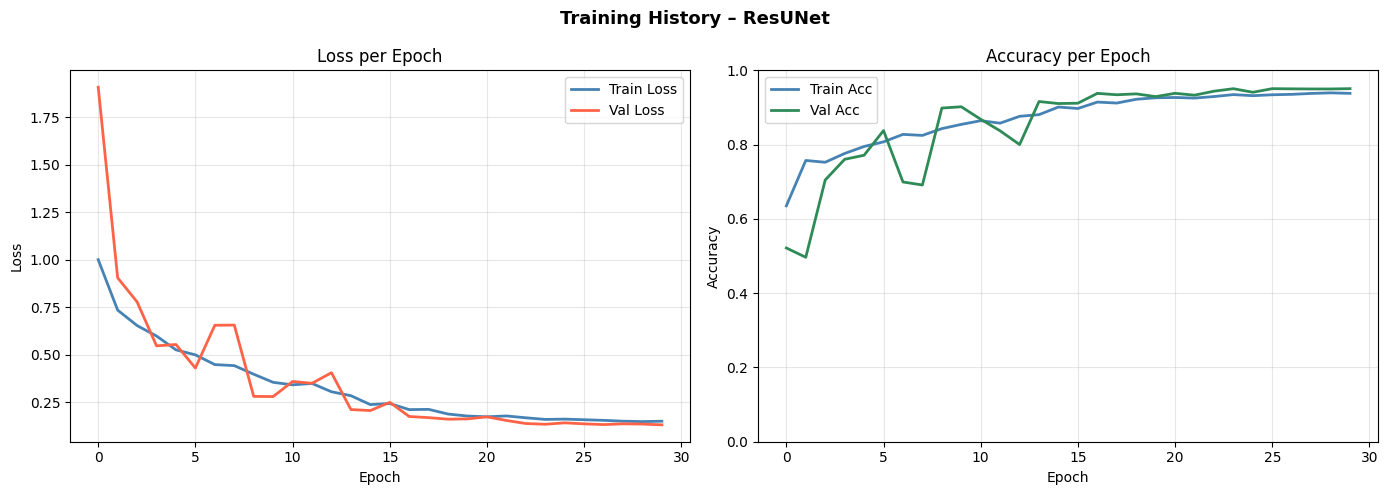

In [17]:
plot_history(resunet_history, "ResUNet")


Training Metrics 

────────────────────────────────────────────────────
Evaluation    ResUNet Train
────────────────────────────────────────────────────
Accuracy        : 0.9444
Precision       : 0.9466
Recall          : 0.9444
F1 Score        : 0.9447
Log Loss        : 0.1594
IoU (Jaccard)   : 0.8967
Dice Score      : 0.9456
────────────────────────────────────────────────────


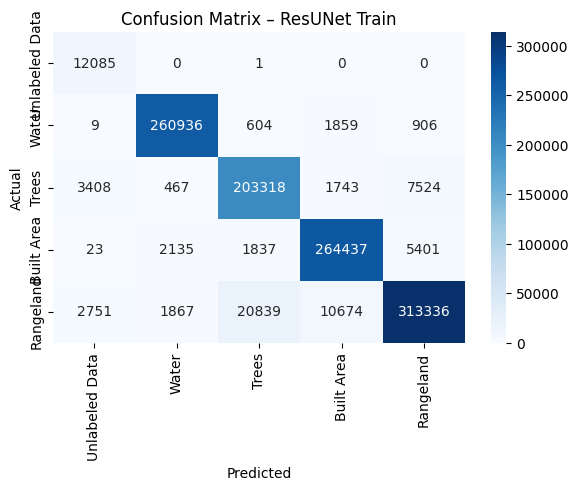

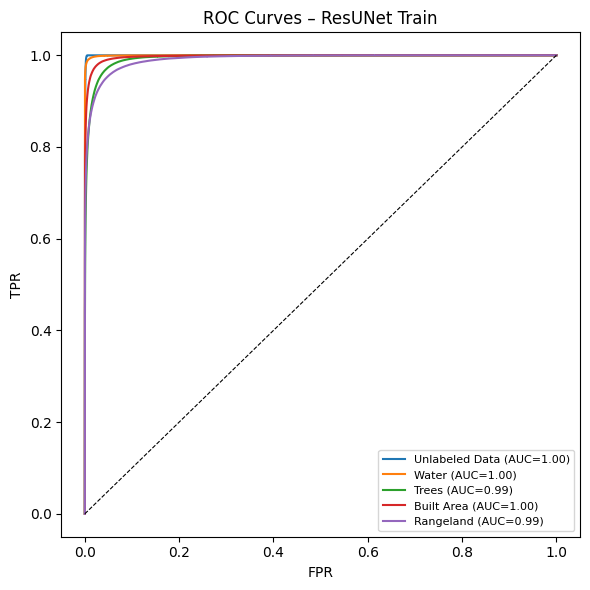

In [18]:
print("\nTraining Metrics ")
resunet_train_m = evaluate(resunet, X_train, y_train, num_classes, device, class_names, "ResUNet Train", show_cm=True, show_roc=True)


Validation Metrics

────────────────────────────────────────────────────
Evaluation    ResUNet Validation
────────────────────────────────────────────────────
Accuracy        : 0.9506
Precision       : 0.9522
Recall          : 0.9506
F1 Score        : 0.9510
Log Loss        : 0.1428
IoU (Jaccard)   : 0.9080
Dice Score      : 0.9518
────────────────────────────────────────────────────


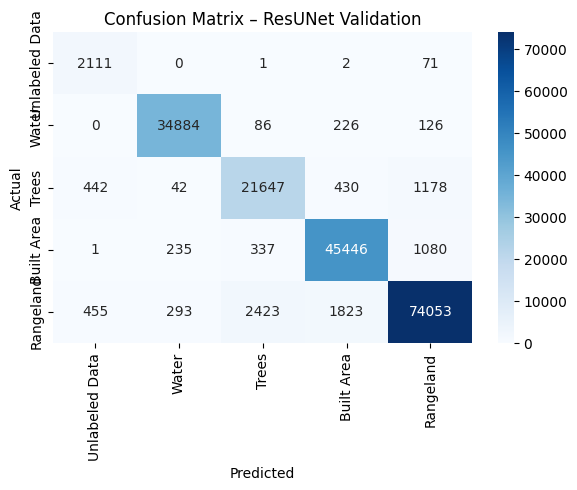

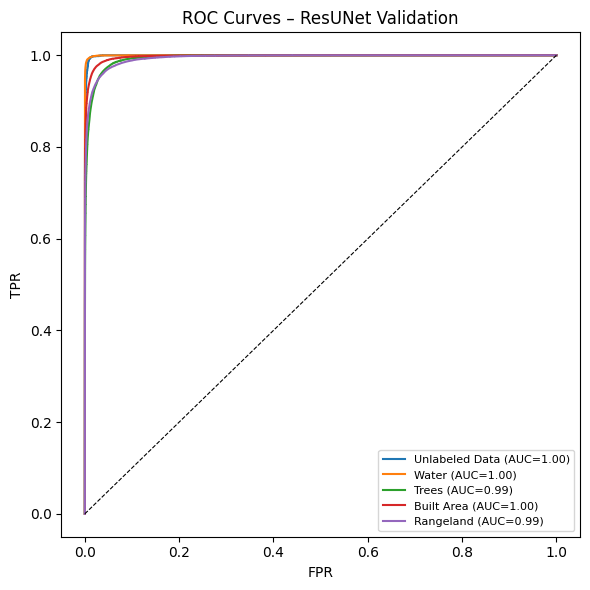

In [19]:
print("\nValidation Metrics")
resunet_val_m = evaluate(resunet, X_val, y_val, num_classes, device, class_names, "ResUNet Validation", show_cm=True, show_roc=True)


Testing Metrics

────────────────────────────────────────────────────
Evaluation    ResUNet Testing
────────────────────────────────────────────────────
Accuracy        : 0.9495
Precision       : 0.9520
Recall          : 0.9495
F1 Score        : 0.9502
Log Loss        : 0.1450
IoU (Jaccard)   : 0.9068
Dice Score      : 0.9511
────────────────────────────────────────────────────


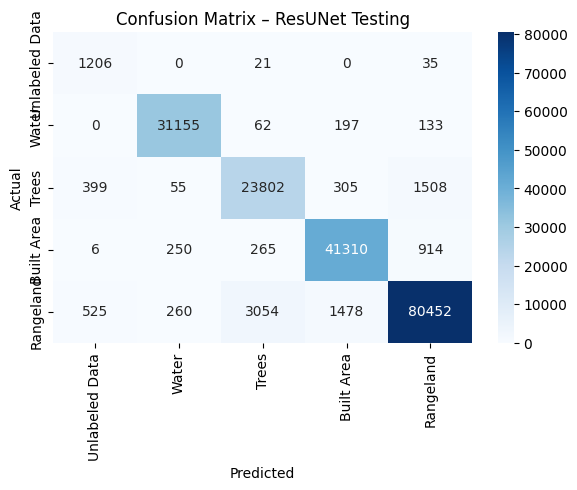

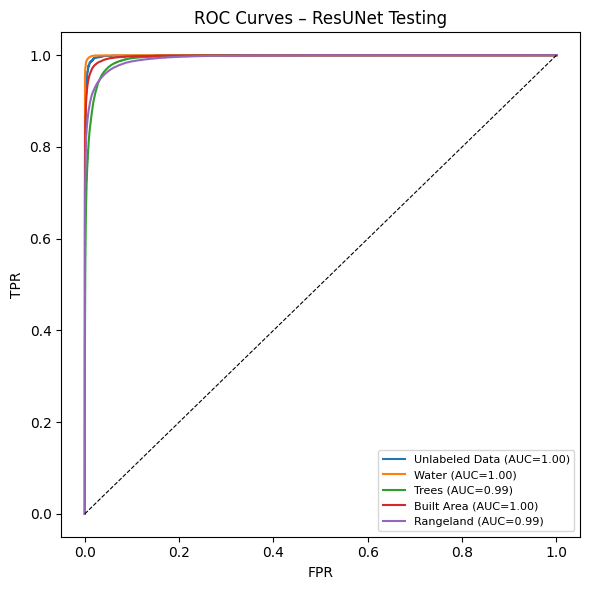

In [20]:
print("\nTesting Metrics")
resunet_test_m = evaluate(resunet, X_test, y_test, num_classes, device, class_names, "ResUNet Testing", show_cm=True, show_roc=True)

comparison_metrics["ResUNet"] = resunet_test_m

## Model 3 - EfficientNet-B0 U-Net

In [21]:
class EfficientNetB0UNet(nn.Module):
    def __init__(self, in_channels, num_classes, dropout=0.1):
        super().__init__()
        base_model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        encoder = base_model.features
        
        self.enc0 = nn.Sequential(nn.Conv2d(in_channels, 32, kernel_size=3, stride=2, padding=1, bias=False), encoder[0][1],encoder[0][2])
        self.enc1 = encoder[1]
        self.enc2 = encoder[2]
        self.enc3 = encoder[3]
        self.bottleneck = encoder[4:6]
        self.up3 = nn.ConvTranspose2d(112, 64, 2, stride=2)
        self.dec3 = conv_block(64 + 40, 64)
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = conv_block(32 + 24, 32)        
        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec1 = conv_block(16 + 16, 16)        
        self.up0 = nn.ConvTranspose2d(16, 16, 2, stride=2)
        self.final_conv = nn.Conv2d(16, num_classes, kernel_size=1)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        e0 = self.enc0(x)
        e1 = self.enc1(e0)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        b = self.bottleneck(e3)
        
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        d0 = self.up0(d1)
        return self.final_conv(d0)

In [22]:
# Summary of the model 

efficientnet_model = EfficientNetB0UNet(in_channels, num_classes).to(device)
summary(efficientnet_model, input_size=(1, in_channels, PATCH_SIZE, PATCH_SIZE), col_names=["input_size","output_size","num_params"])

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #
EfficientNetB0UNet                                      [1, 5, 32, 32]            [1, 5, 32, 32]            --
├─Sequential: 1-1                                       [1, 5, 32, 32]            [1, 32, 16, 16]           --
│    └─Conv2d: 2-1                                      [1, 5, 32, 32]            [1, 32, 16, 16]           1,440
│    └─BatchNorm2d: 2-2                                 [1, 32, 16, 16]           [1, 32, 16, 16]           64
│    └─SiLU: 2-3                                        [1, 32, 16, 16]           [1, 32, 16, 16]           --
├─Sequential: 1-2                                       [1, 32, 16, 16]           [1, 16, 16, 16]           --
│    └─MBConv: 2-4                                      [1, 32, 16, 16]           [1, 16, 16, 16]           --
│    │    └─Sequential: 3-1                             [1, 32, 16, 16]           [1, 16, 16, 16]       

In [23]:
efficientnet_model, efficientnet_history = train_model(efficientnet_model, "EfficientNet-B0-UNet",X_train, y_train, X_val, y_val, lr=5e-4, epochs=EPOCHS, scheduler_type="cosine")


                       TRAINING STARTED                       

[Epoch 01/30] Loss=1.5553  ValAcc=0.2172  Time=1.40s
[Epoch 02/30] Loss=1.3747  ValAcc=0.5012  Time=0.85s
[Epoch 03/30] Loss=1.1813  ValAcc=0.5344  Time=0.65s
[Epoch 04/30] Loss=1.0207  ValAcc=0.5190  Time=0.66s
[Epoch 05/30] Loss=0.8935  ValAcc=0.5073  Time=0.65s
[Epoch 06/30] Loss=0.7893  ValAcc=0.5671  Time=0.81s
[Epoch 07/30] Loss=0.7234  ValAcc=0.6123  Time=0.86s
[Epoch 08/30] Loss=0.6581  ValAcc=0.7049  Time=0.84s
[Epoch 09/30] Loss=0.5818  ValAcc=0.7554  Time=0.92s
[Epoch 10/30] Loss=0.5463  ValAcc=0.8131  Time=0.80s
[Epoch 11/30] Loss=0.5198  ValAcc=0.8173  Time=0.80s
[Epoch 12/30] Loss=0.4773  ValAcc=0.8420  Time=0.83s
[Epoch 13/30] Loss=0.4329  ValAcc=0.8580  Time=0.65s
[Epoch 14/30] Loss=0.4031  ValAcc=0.8653  Time=0.66s
[Epoch 15/30] Loss=0.3832  ValAcc=0.8600  Time=0.82s
[Epoch 16/30] Loss=0.3863  ValAcc=0.8550  Time=0.66s
[Epoch 17/30] Loss=0.3684  ValAcc=0.8635  Time=0.76s
[Epoch 18/30] Loss=0.3453  ValAcc=

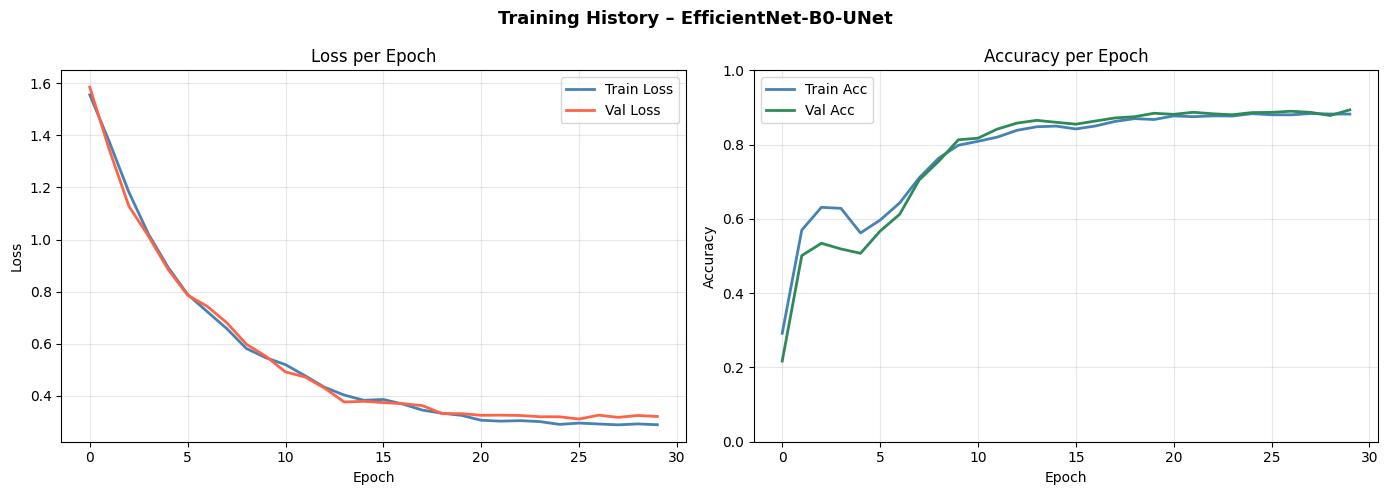

In [24]:
plot_history(efficientnet_history, "EfficientNet-B0-UNet")


 Training Metrics

────────────────────────────────────────────────────
Evaluation    EfficientNet Training 
────────────────────────────────────────────────────
Accuracy        : 0.8975
Precision       : 0.9005
Recall          : 0.8975
F1 Score        : 0.8979
Log Loss        : 0.3108
IoU (Jaccard)   : 0.8190
Dice Score      : 0.9005
────────────────────────────────────────────────────


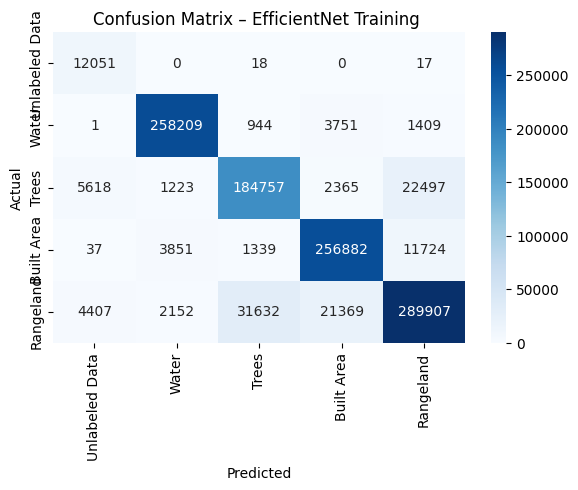

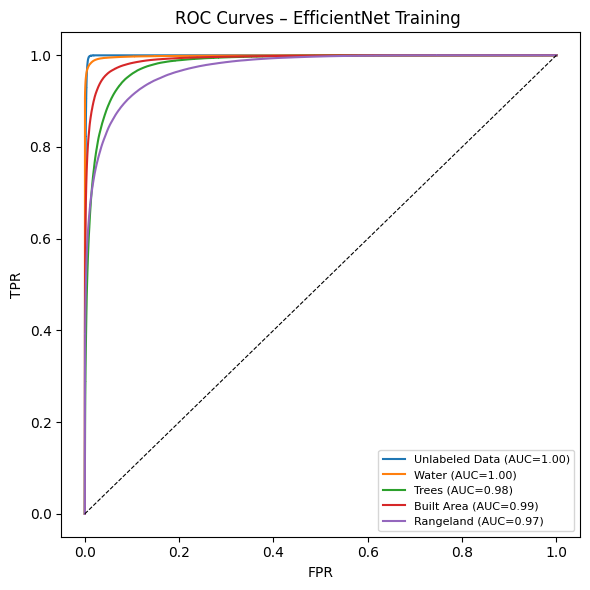

In [25]:
print("\n Training Metrics")
eff_train_m = evaluate(efficientnet_model, X_train, y_train, num_classes, device, class_names, "EfficientNet Training ", show_cm=True, show_roc=True)


 Validation Metrics

────────────────────────────────────────────────────
Evaluation    EfficientNet Validation
────────────────────────────────────────────────────
Accuracy        : 0.8936
Precision       : 0.8952
Recall          : 0.8936
F1 Score        : 0.8939
Log Loss        : 0.3202
IoU (Jaccard)   : 0.8128
Dice Score      : 0.8967
────────────────────────────────────────────────────


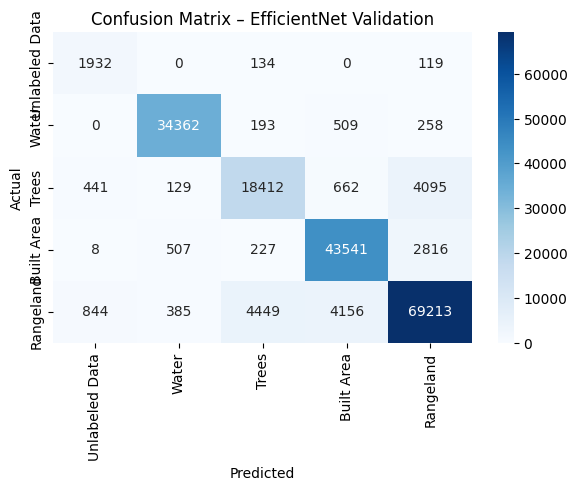

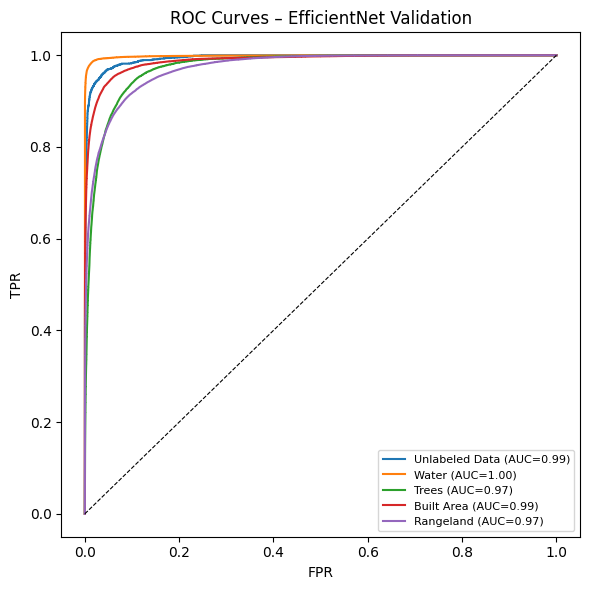

In [26]:
print("\n Validation Metrics")
eff_val_m = evaluate(efficientnet_model, X_val, y_val, num_classes, device, class_names, "EfficientNet Validation", show_cm=True, show_roc=True)


Testing Metrics

────────────────────────────────────────────────────
Evaluation    EfficientNet Testing 
────────────────────────────────────────────────────
Accuracy        : 0.8934
Precision       : 0.8980
Recall          : 0.8934
F1 Score        : 0.8947
Log Loss        : 0.3234
IoU (Jaccard)   : 0.8141
Dice Score      : 0.8975
────────────────────────────────────────────────────


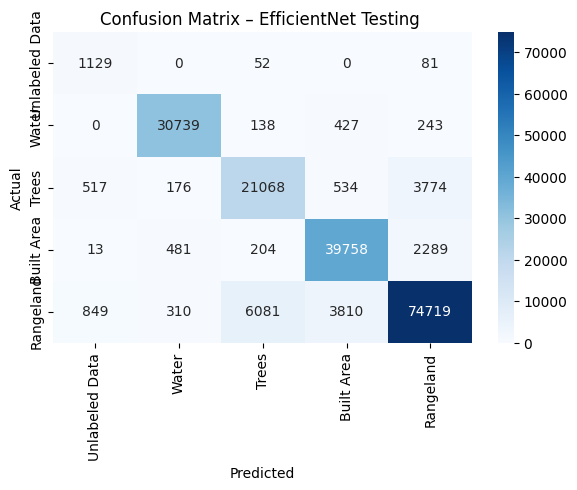

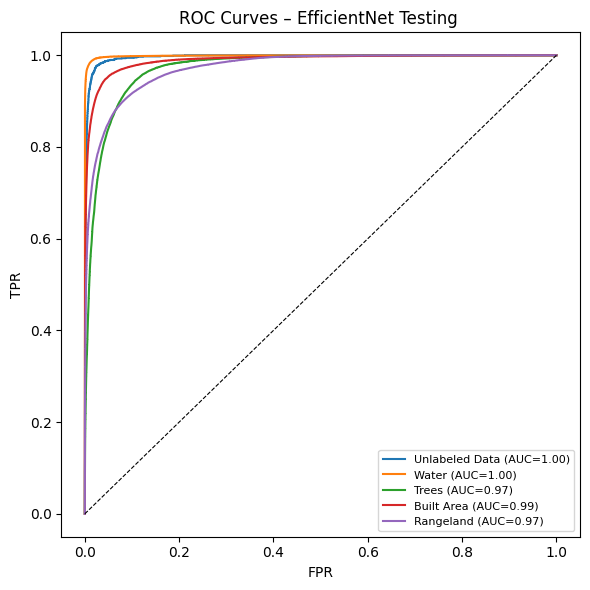

In [27]:
print("\nTesting Metrics")
eff_test_m = evaluate(efficientnet_model, X_test, y_test, num_classes, device, class_names, "EfficientNet Testing ", show_cm=True, show_roc=True)

comparison_metrics["EfficientNetB0-UNet"] = eff_test_m

## Primary Comparison of the Three Models 

In [28]:
df_compare = pd.DataFrame(comparison_metrics).T.round(4)
print("\n" + "="*81)
print(f"{'BASELINE COMPARISON TABLE':^81}")
print("="*81)
print(df_compare.to_string())
print("="*81)


                            BASELINE COMPARISON TABLE                            
                     Accuracy  Precision  Recall      F1  LogLoss     IoU    Dice
U-Net                  0.9194     0.9297  0.9194  0.9215   0.2440  0.8576  0.9233
ResUNet                0.9495     0.9520  0.9495  0.9502   0.1450  0.9068  0.9511
EfficientNetB0-UNet    0.8934     0.8980  0.8934  0.8947   0.3234  0.8141  0.8975


In [29]:
best_model_name = df_compare["IoU"].idxmax()
print(f"Best baseline model : {best_model_name}\n"
      f"\nThe Testing Metrics are as follows :"
      f"\nIoU = {df_compare.loc[best_model_name,'IoU']:.4f}"
      f"\nF1 = {df_compare.loc[best_model_name,'F1']:.4f}"
      f"\nAccuracy = {df_compare.loc[best_model_name, 'Accuracy']:.4f}")

Best baseline model : ResUNet

The Testing Metrics are as follows :
IoU = 0.9068
F1 = 0.9502
Accuracy = 0.9495


## Hyperparameter Tuning of the Best Model 

In [30]:
hp_grid = {"lr":[1e-3, 5e-4], "dropout": [0.0, 0.3], "scheduler": ["cosine", "step", "none"]}
SEARCH_EPOCHS = 20
hp_results = []

print(f"{'='*58}")
print(f"{best_model_name + ' HYPERPARAMETER SEARCH':^58}")
print(f"{'='*58}\n")
print(f"{'lr':>10} {'dropout':>8} {'sched':>8} {'ValAcc':>10} {'ValLoss':>10}")
print("─" * 58)

for lr, dr, sched in iterproduct(hp_grid["lr"], hp_grid["dropout"], hp_grid["scheduler"]):
    set_seed()
    if best_model_name == "EfficientNetB0-UNet":
        m = EfficientNetB0UNet(in_channels, num_classes, dropout=dr).to(device)
    elif best_model_name == "ResUNet":
        m = ResUNet(in_channels, num_classes, dropout=dr).to(device)
    else:
        m = UNet(in_channels, num_classes, dropout=dr).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(m.parameters(), lr=lr, weight_decay=1e-4)

    if sched == "cosine":
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=SEARCH_EPOCHS)
    elif sched == "step":
        scheduler = optim.lr_scheduler.StepLR(optimizer,step_size=7,gamma=0.5)
    else:
        scheduler = None

    train_ds = AugmentedDataset(X_train, y_train)
    val_ds = AugmentedDataset(X_val, y_val)
    train_ld = DataLoader(train_ds,batch_size=BATCH_SIZE, shuffle=True,num_workers=0)
    val_ld = DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=0)

    for epoch in range(SEARCH_EPOCHS):
        m.train()
        for bx, by in train_ld:
            bx = bx.to(device)
            by = by.to(device)
            optimizer.zero_grad()
            out = m(bx)
            loss = criterion(out, by)
            loss.backward()
            optimizer.step()

        if scheduler is not None:
            scheduler.step()
            
    m.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for bx, by in val_ld:
            bx = bx.to(device)
            by = by.to(device)
            out = m(bx)
            val_loss += criterion(out, by).item() * len(bx)
            preds = out.argmax(dim=1)
            correct += (preds == by).sum().item()
            total += by.numel()

    vacc = correct / total * 100 
    vloss = val_loss / len(val_ds)
    hp_results.append({"lr": lr, "dropout": dr, "scheduler": sched, "val_acc": vacc, "val_loss": vloss})
    print(f"{lr:>10.1} "
        f"{dr:>8.2f} "
        f"{sched:>8} "
        f"{vacc:>9.2f}% "
        f"{vloss:>10.4f}"
    )

              ResUNet HYPERPARAMETER SEARCH               

        lr  dropout    sched     ValAcc    ValLoss
──────────────────────────────────────────────────────────
     0.001     0.00   cosine     94.78%     0.1535
     0.001     0.00     step     94.53%     0.1618
     0.001     0.00     none     92.74%     0.1971
     0.001     0.30   cosine     92.05%     0.2318
     0.001     0.30     step     91.97%     0.2326
     0.001     0.30     none     91.76%     0.2410
    0.0005     0.00   cosine     94.94%     0.1583
    0.0005     0.00     step     95.06%     0.1533
    0.0005     0.00     none     95.46%     0.1354
    0.0005     0.30   cosine     91.09%     0.2625
    0.0005     0.30     step     91.24%     0.2541
    0.0005     0.30     none     91.84%     0.2364


In [31]:
best_hp = max(hp_results, key=lambda x: x["val_acc"])
print(f"Best Configuration of the Hyperparameter is as follows :")
print(f"Learning Rate = {best_hp['lr']}")
print(f"Dropout = {best_hp['dropout']}")
print(f"Scheduler = {best_hp['scheduler']}\n")
print("The Validation Metrics is as follows :")
print(f"Val Acc = {best_hp['val_acc']:.4f}% ")
print(f"Val Loss = {best_hp['val_loss']:.4f}")

Best Configuration of the Hyperparameter is as follows :
Learning Rate = 0.0005
Dropout = 0.0
Scheduler = none

The Validation Metrics is as follows :
Val Acc = 95.4603% 
Val Loss = 0.1354


### Full Training with Best Hyperparameters


                       TRAINING STARTED                       

[Epoch 01/30] Loss=0.9656  ValAcc=0.5849  Time=0.41s
[Epoch 02/30] Loss=0.7265  ValAcc=0.6145  Time=0.37s
[Epoch 03/30] Loss=0.6464  ValAcc=0.6513  Time=0.43s
[Epoch 04/30] Loss=0.5741  ValAcc=0.8449  Time=0.38s
[Epoch 05/30] Loss=0.5042  ValAcc=0.8664  Time=0.39s
[Epoch 06/30] Loss=0.4791  ValAcc=0.7739  Time=0.40s
[Epoch 07/30] Loss=0.4276  ValAcc=0.7685  Time=0.40s
[Epoch 08/30] Loss=0.3766  ValAcc=0.8283  Time=0.39s
[Epoch 09/30] Loss=0.3389  ValAcc=0.8961  Time=0.38s
[Epoch 10/30] Loss=0.2989  ValAcc=0.9000  Time=0.35s
[Epoch 11/30] Loss=0.2739  ValAcc=0.8673  Time=0.35s
[Epoch 12/30] Loss=0.2277  ValAcc=0.8314  Time=0.35s
[Epoch 13/30] Loss=0.2599  ValAcc=0.8911  Time=0.35s
[Epoch 14/30] Loss=0.2140  ValAcc=0.9440  Time=0.35s
[Epoch 15/30] Loss=0.1784  ValAcc=0.9377  Time=0.35s
[Epoch 16/30] Loss=0.1767  ValAcc=0.9401  Time=0.34s
[Epoch 17/30] Loss=0.2770  ValAcc=0.8987  Time=0.35s
[Epoch 18/30] Loss=0.2068  ValAcc=

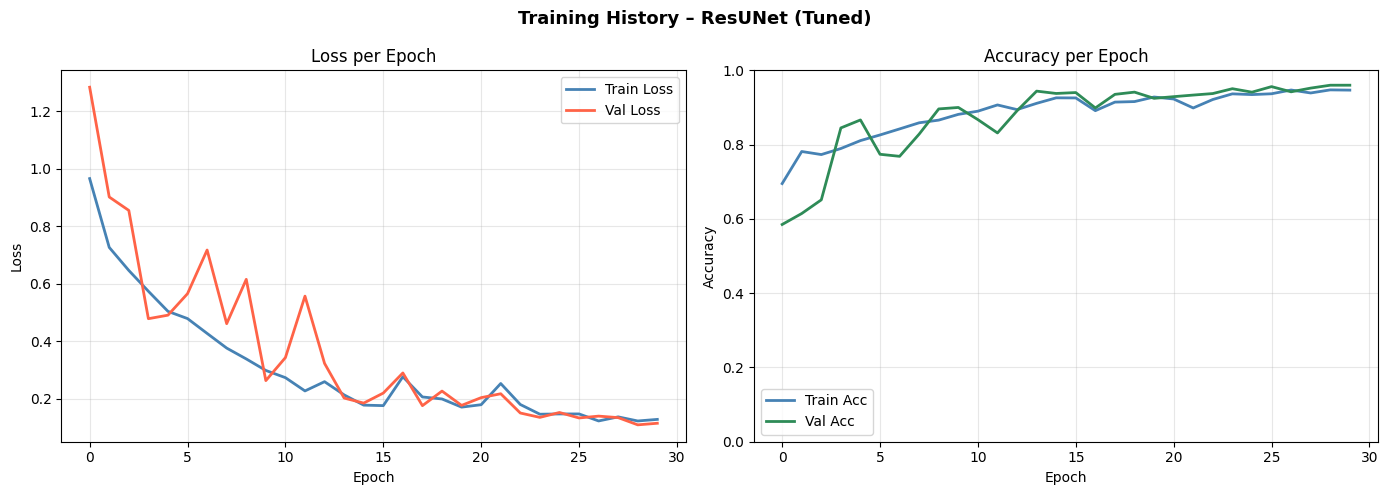

In [32]:
# Create model with best hyperparameters
if best_model_name == "EfficientNetB0-UNet":
    best_m = EfficientNetB0UNet(in_channels, num_classes, dropout=best_hp["dropout"]).to(device)
elif best_model_name == "ResUNet":
    best_m = ResUNet(in_channels, num_classes, dropout=best_hp["dropout"]).to(device)
else:
    best_m = UNet(in_channels, num_classes, dropout=best_hp["dropout"]).to(device)

best_m, best_history = train_model(best_m, f"{best_model_name} (Tuned)", X_train, y_train, X_val, y_val, lr=best_hp["lr"], epochs=EPOCHS, scheduler_type=best_hp["scheduler"])

plot_history(best_history, f"{best_model_name} (Tuned)")


 Training Metrics

────────────────────────────────────────────────────
Evaluation    ResUNet Tuned Training 
────────────────────────────────────────────────────
Accuracy        : 0.9554
Precision       : 0.9568
Recall          : 0.9554
F1 Score        : 0.9557
Log Loss        : 0.1294
IoU (Jaccard)   : 0.9158
Dice Score      : 0.9561
────────────────────────────────────────────────────


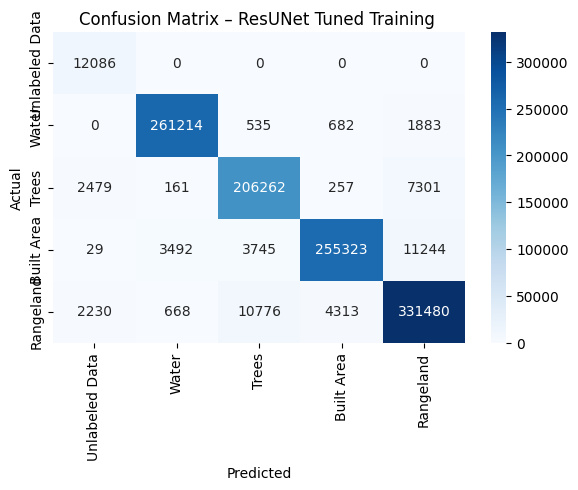

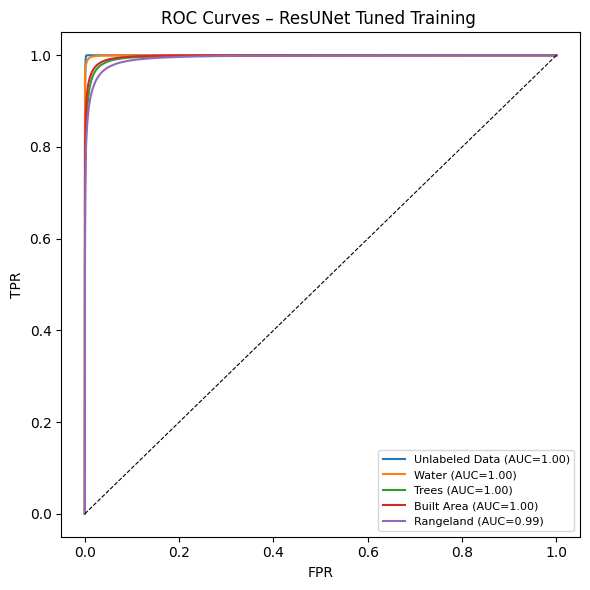

In [33]:
print("\n Training Metrics")
eff_train_m = evaluate(best_m, X_train, y_train, num_classes, device, class_names, f"{best_model_name} Tuned Training ", show_cm=True, show_roc=True)


 Validation Metrics

────────────────────────────────────────────────────
Evaluation    ResUNet Tuned Validation 
────────────────────────────────────────────────────
Accuracy        : 0.9600
Precision       : 0.9608
Recall          : 0.9600
F1 Score        : 0.9601
Log Loss        : 0.1166
IoU (Jaccard)   : 0.9240
Dice Score      : 0.9605
────────────────────────────────────────────────────


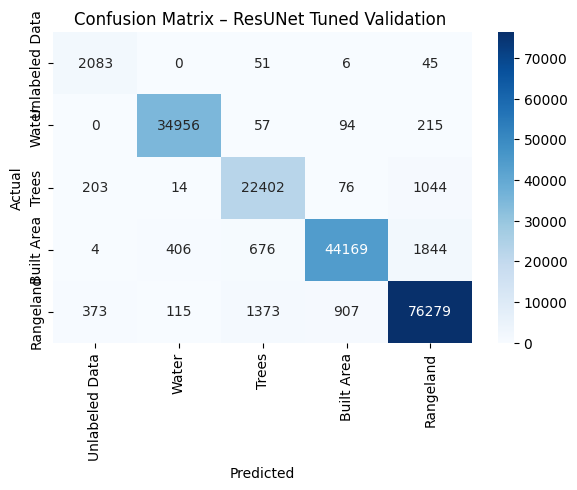

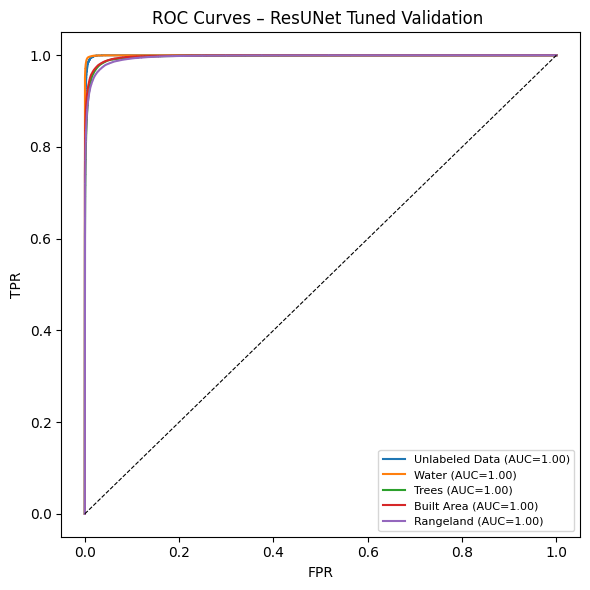

In [34]:
print("\n Validation Metrics")
eff_val_m = evaluate(best_m, X_val, y_val, num_classes, device, class_names, f"{best_model_name} Tuned Validation ", show_cm=True, show_roc=True)


 Test Evaluation :  ResUNet (Tuned)

────────────────────────────────────────────────────
Evaluation    ResUNet Tuned Testing 
────────────────────────────────────────────────────
Accuracy        : 0.9590
Precision       : 0.9604
Recall          : 0.9590
F1 Score        : 0.9594
Log Loss        : 0.1194
IoU (Jaccard)   : 0.9228
Dice Score      : 0.9598
────────────────────────────────────────────────────


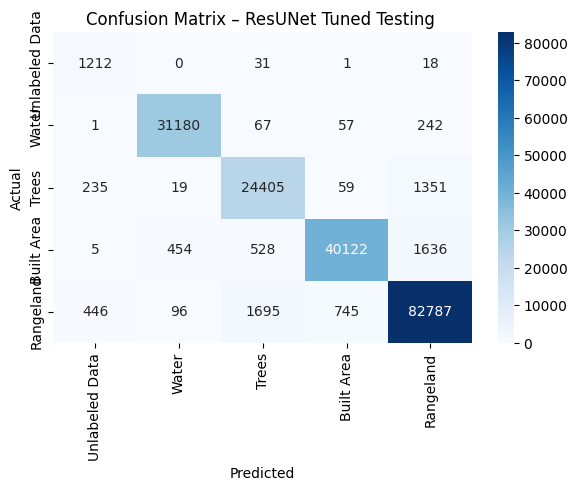

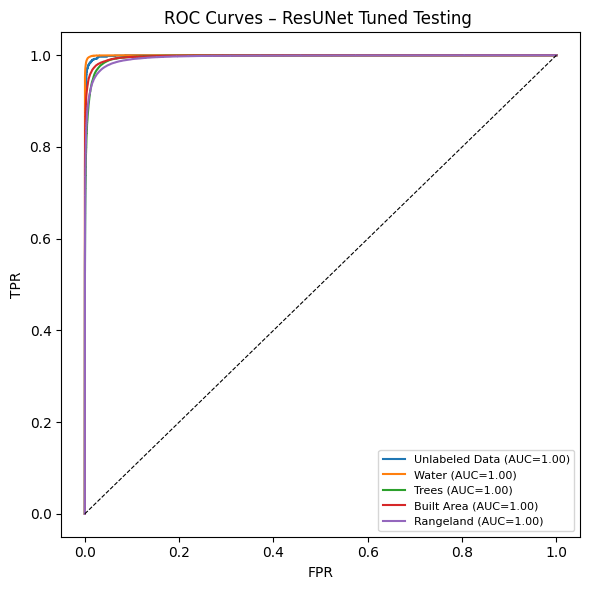

In [35]:
print(f"\n Test Evaluation :  {best_model_name} (Tuned)")
best_tuned_m = evaluate(best_m, X_test, y_test, num_classes, device,class_names, f"{best_model_name} Tuned Testing ",show_cm=True, show_roc=True)

comparison_metrics[f"{best_model_name} (Tuned)"] = best_tuned_m

## Comparison of all the Models 

In [36]:
df_final = pd.DataFrame(comparison_metrics).T.round(4)
print("\n" + "="*81)
print(f"{'FINAL COMPARISON TABLE':^81}")
print("="*81)
print(df_final.to_string())
print("="*81)


                             FINAL COMPARISON TABLE                              
                     Accuracy  Precision  Recall      F1  LogLoss     IoU    Dice
U-Net                  0.9194     0.9297  0.9194  0.9215   0.2440  0.8576  0.9233
ResUNet                0.9495     0.9520  0.9495  0.9502   0.1450  0.9068  0.9511
EfficientNetB0-UNet    0.8934     0.8980  0.8934  0.8947   0.3234  0.8141  0.8975
ResUNet (Tuned)        0.9590     0.9604  0.9590  0.9594   0.1194  0.9228  0.9598


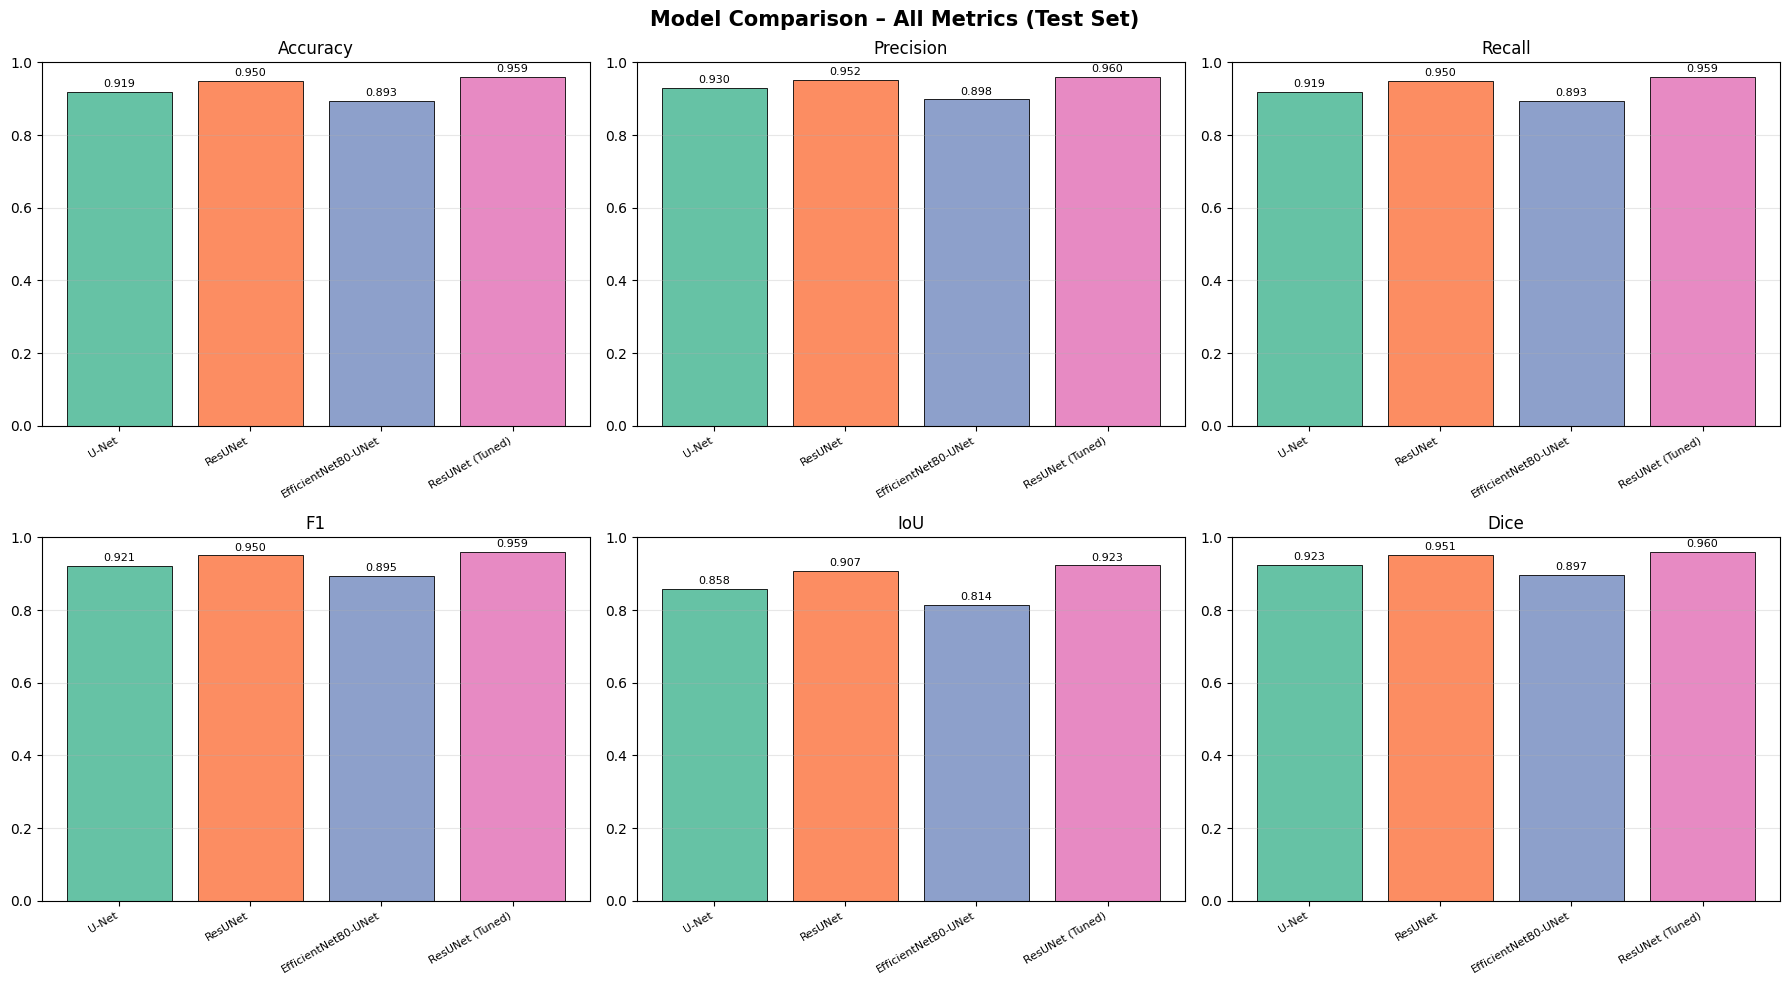

In [37]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "IoU", "Dice"]
df_plot = df_final[metrics_to_plot]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Model Comparison – All Metrics (Test Set)", fontsize=15, fontweight="bold")
colors = plt.cm.Set2.colors

for ax, metric in zip(axes.flat, metrics_to_plot):
    bars = ax.bar(df_plot.index, df_plot[metric], color=colors[:len(df_plot)], edgecolor="k", linewidth=0.6)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_xticks(range(len(df_plot)))
    ax.set_xticklabels(df_plot.index, rotation=30, ha="right", fontsize=8)
    ax.bar_label(bars, fmt="%.3f", fontsize=8, padding=2)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

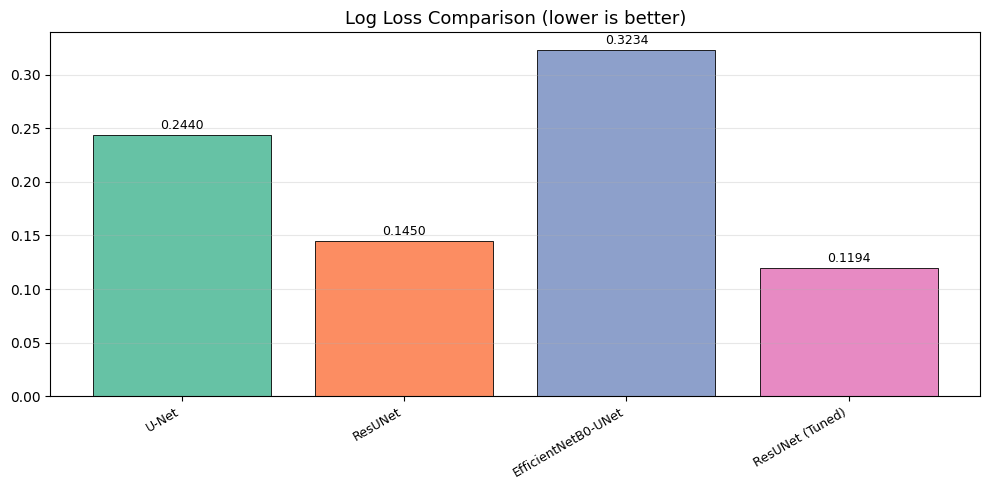

In [ ]:
# Log Loss (lower is better)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(df_final.index, df_final["LogLoss"], color=colors[:len(df_final)], edgecolor="k", linewidth=0.6)
ax.set_title("Log Loss Comparison (lower is better)", fontsize=13)
ax.set_xticks(range(len(df_final)))
ax.set_xticklabels(df_final.index, rotation=30, ha="right", fontsize=9)
ax.bar_label(bars, fmt="%.4f", fontsize=9, padding=2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()